# Option Pricing on Airbus — Black-Scholes and Monte Carlo

This notebook summarizes the project in a single document.

We price European options on Airbus stock (AIR.PA) using:
- the Black-Scholes analytical model
- a Monte Carlo simulation

We also analyze:
- option Greeks (delta, gamma, vega, theta)
- parameter sensitivities (volatility, interest rate, maturity)
- model limitations

## Market Data

We use real market data retrieved via yfinance.

- Underlying: Airbus (AIR.PA)
- S0: latest closing price
- Volatility: estimated from historical returns

In [1]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf

## 1. Market Data and Assumptions

We use Airbus market data downloaded from Yahoo Finance.

The latest adjusted close is used as the spot price \(S_0\), and
historical volatility is estimated from rolling log-return volatility.

In [3]:
# Download Airbus market data
airbus_raw = yf.download("AIR.PA", period="2y", auto_adjust=False)

# Keep adjusted close in a robust way
adj_close = airbus_raw["Adj Close"].copy()

# If Adj Close is already a DataFrame, keep its first column only
if isinstance(adj_close, pd.DataFrame):
    adj_close = adj_close.iloc[:, 0]

# Build a clean one-column DataFrame
airbus = pd.DataFrame({"Adj Close": adj_close}).dropna()

# Log returns and annualized rolling volatilities
airbus["log_return"] = np.log(airbus["Adj Close"] / airbus["Adj Close"].shift(1))
airbus["vol_20d"] = airbus["log_return"].rolling(20).std() * np.sqrt(252)
airbus["vol_60d"] = airbus["log_return"].rolling(60).std() * np.sqrt(252)

airbus = airbus.dropna()

# Base market inputs
S0 = float(airbus["Adj Close"].iloc[-1])
sigma_20 = float(airbus["vol_20d"].iloc[-1])
sigma_60 = float(airbus["vol_60d"].iloc[-1])

# Other pricing parameters
r = 0.02
T_30 = 30 / 252
T_90 = 90 / 252
K_atm = round(S0, 2)

print(f"S0 = {S0:.2f}")
print(f"sigma_20 = {sigma_20:.4f}")
print(f"sigma_60 = {sigma_60:.4f}")
print(f"ATM strike = {K_atm:.2f}")

print()
strikes = [round(0.90 * S0, 2),round(0.95 * S0, 2),round(1.00 * S0, 2),round(1.05 * S0, 2),round(1.10 * S0, 2),]
print(f"Strikes : {strikes}")

print()
airbus[["Adj Close", "vol_20d", "vol_60d"]].tail()

[*********************100%***********************]  1 of 1 completed

S0 = 157.96
sigma_20 = 0.2856
sigma_60 = 0.2920
ATM strike = 157.96

Strikes : [142.16, 150.06, 157.96, 165.86, 173.76]



,Adj Close,vol_20d,vol_60d
Date,,,
2026-03-25,168.460007,0.292402,0.296761
2026-03-26,163.399994,0.299197,0.302151
2026-03-27,160.419998,0.301188,0.297312
2026-03-30,159.179993,0.296119,0.292839
2026-03-31,157.960007,0.285574,0.291980


## 2. Black-Scholes Model

The Black-Scholes model gives a closed-form formula for European call
and put prices

**C = S N(d1) − K e^(−rT) N(d2)**

**P = K e^(−rT) N(-d2) − S N(-d1)**

In [4]:
def d1(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

def bs_call(S, K, T, r, sigma):
    return S * norm.cdf(d1(S, K, T, r, sigma)) - K * np.exp(-r * T) * norm.cdf(d2(S, K, T, r, sigma))

def bs_put(S, K, T, r, sigma):
    return K * np.exp(-r * T) * norm.cdf(-d2(S, K, T, r, sigma)) - S * norm.cdf(-d1(S, K, T, r, sigma))

In [5]:
results = []

for K in strikes:
    results.append({
        "Strike": float(K),
        "Call_30d_sigma20": float(bs_call(S0, K, T_30, r, sigma_20)),
        "Put_30d_sigma20": float(bs_put(S0, K, T_30, r, sigma_20)),
        "Call_30d_sigma60": float(bs_call(S0, K, T_30, r, sigma_60)),
        "Put_30d_sigma60": float(bs_put(S0, K, T_30, r, sigma_60)),
        "Call_90d_sigma20": float(bs_call(S0, K, T_90, r, sigma_20)),
        "Put_90d_sigma20": float(bs_put(S0, K, T_90, r, sigma_20)),
        "Call_90d_sigma60": float(bs_call(S0, K, T_90, r, sigma_60)),
        "Put_90d_sigma60": float(bs_put(S0, K, T_90, r, sigma_60)),})

pricing_table = pd.DataFrame(results).round(4)
pricing_table

,Strike,Call_30d_sigma20,Put_30d_sigma20,Call_30d_sigma60,Put_30d_sigma60,Call_90d_sigma20,Put_90d_sigma20,Call_90d_sigma60,Put_90d_sigma60
0,142.16,17.1618,1.0237,17.2353,1.0972,20.7020,3.8902,20.8857,4.0739
1,150.06,11.0476,2.7908,11.1648,2.9079,15.5252,6.5572,15.7456,6.7776
2,157.96,6.3889,6.0133,6.5279,6.1522,11.2749,10.1506,11.5142,10.3899
3,165.86,3.2931,10.7986,3.4208,10.9264,7.9347,14.6542,8.1731,14.8926
4,173.76,1.5102,16.8970,1.6045,16.9913,5.4182,19.9814,5.6386,20.2019


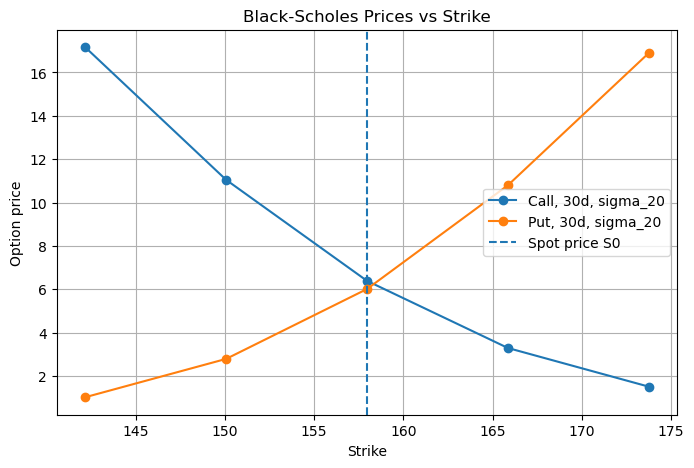

In [6]:
plt.figure(figsize=(8,5))
plt.plot(pricing_table["Strike"], pricing_table["Call_30d_sigma20"], marker="o", label="Call, 30d, sigma_20")
plt.plot(pricing_table["Strike"], pricing_table["Put_30d_sigma20"], marker="o", label="Put, 30d, sigma_20")
plt.axvline(S0, linestyle="--", label="Spot price S0")
plt.title("Black-Scholes Prices vs Strike")
plt.xlabel("Strike")
plt.ylabel("Option price")
plt.legend()
plt.grid(True)
plt.show()

The call price decreases as the strike increases, while the put price
increases. This is the standard behavior predicted by the Black-Scholes model.

## 3. Analytical Greeks

Greeks measure the sensitivity of option prices to key model parameters.
We illustrate the main analytical Greeks around the at-the-money region.

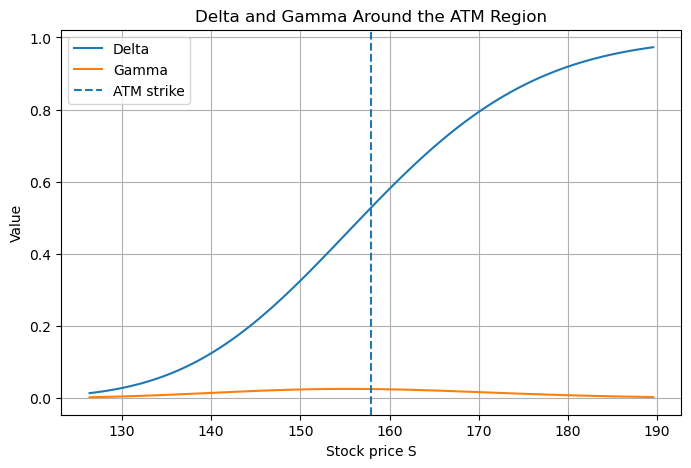

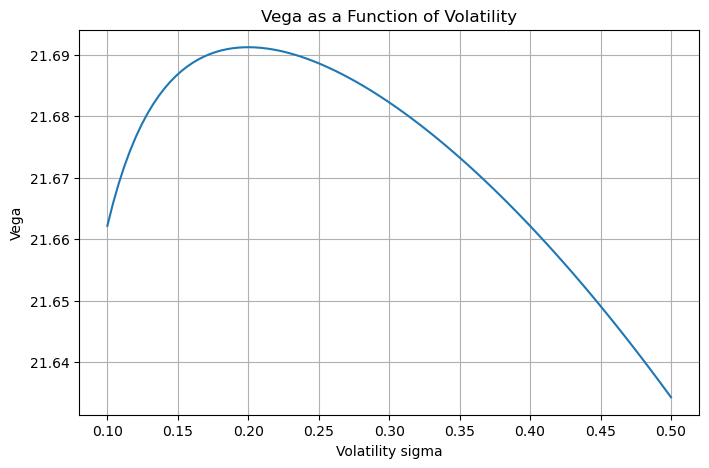

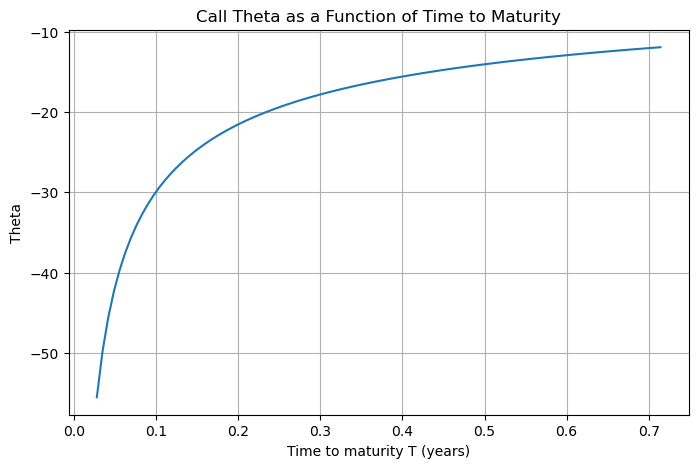

In [7]:
def delta_call(S, K, T, r, sigma):
    return norm.cdf(d1(S, K, T, r, sigma))

def gamma(S, K, T, r, sigma):
    return norm.pdf(d1(S, K, T, r, sigma)) / (S * sigma * np.sqrt(T))

def vega(S, K, T, r, sigma):
    return S * norm.pdf(d1(S, K, T, r, sigma)) * np.sqrt(T)

def theta_call(S, K, T, r, sigma):
    d1_value = d1(S, K, T, r, sigma)
    d2_value = d2(S, K, T, r, sigma)
    return - (S * norm.pdf(d1_value) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2_value)

S_values = np.linspace(0.8 * S0, 1.2 * S0, 100)
sigma_values = np.linspace(0.1, 0.5, 100)
T_values = np.linspace(7/252, 180/252, 100)


delta_values = [delta_call(S, K_atm, T_30, r, sigma_20) for S in S_values]
gamma_values = [gamma(S, K_atm, T_30, r, sigma_20) for S in S_values]

plt.figure(figsize=(8,5))
plt.plot(S_values, delta_values, label="Delta")
plt.plot(S_values, gamma_values, label="Gamma")
plt.axvline(K_atm, linestyle="--", label="ATM strike")
plt.title("Delta and Gamma Around the ATM Region")
plt.xlabel("Stock price S")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

vega_values = [vega(S0, K_atm, T_30, r, sigma) for sigma in sigma_values]
theta_values = [theta_call(S0, K_atm, T, r, sigma_20) for T in T_values]

plt.figure(figsize=(8,5))
plt.plot(sigma_values, vega_values)
plt.title("Vega as a Function of Volatility")
plt.xlabel("Volatility sigma")
plt.ylabel("Vega")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(T_values, theta_values)
plt.title("Call Theta as a Function of Time to Maturity")
plt.xlabel("Time to maturity T (years)")
plt.ylabel("Theta")
plt.grid(True)
plt.show()

## 4. Monte Carlo Pricing

Monte Carlo simulation estimates option prices by simulating many
possible terminal stock prices under the Black-Scholes assumptions.

Black-Scholes call price: 6.3889
Monte Carlo call price: 6.3896


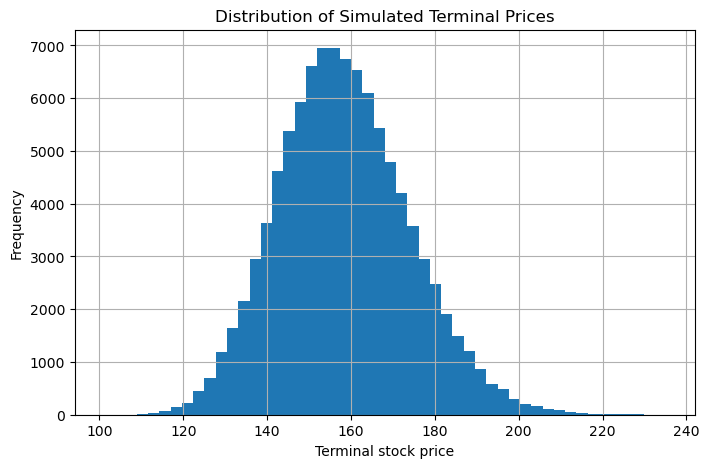

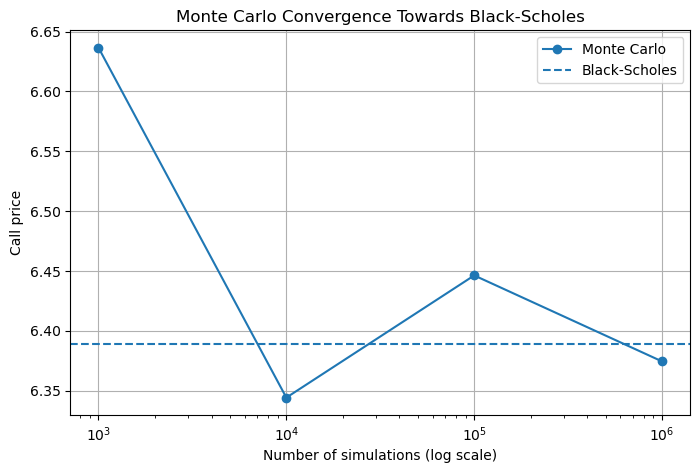

In [8]:
def mc_call_price(S0, K, T, r, sigma, N):
    Z = np.random.normal(size=N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    return np.exp(-r * T) * np.mean(payoff)

bs_price = bs_call(S0, K_atm, T_30, r, sigma_20)
mc_price = mc_call_price(S0, K_atm, T_30, r, sigma_20, 100000)

print(f"Black-Scholes call price: {bs_price:.4f}")
print(f"Monte Carlo call price: {mc_price:.4f}")

N = 100000
Z = np.random.normal(size=N)
ST = S0 * np.exp((r - 0.5 * sigma_20**2) * T_30 + sigma_20 * np.sqrt(T_30) * Z)

plt.figure(figsize=(8,5))
plt.hist(ST, bins=50)
plt.title("Distribution of Simulated Terminal Prices")
plt.xlabel("Terminal stock price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

N_values = [1000, 10000, 100000, 1000000]
mc_prices = [mc_call_price(S0, K_atm, T_30, r, sigma_20, N) for N in N_values]

plt.figure(figsize=(8,5))
plt.plot(N_values, mc_prices, marker="o", label="Monte Carlo")
plt.axhline(bs_price, linestyle="--", label="Black-Scholes")
plt.xscale("log")
plt.title("Monte Carlo Convergence Towards Black-Scholes")
plt.xlabel("Number of simulations (log scale)")
plt.ylabel("Call price")
plt.legend()
plt.grid(True)
plt.show()

The Monte Carlo estimate converges towards the Black-Scholes benchmark
as the number of simulations increases.

## 5. Sensitivity Analysis

We summarize the impact of:
- the risk-free rate
- volatility
- time to maturity

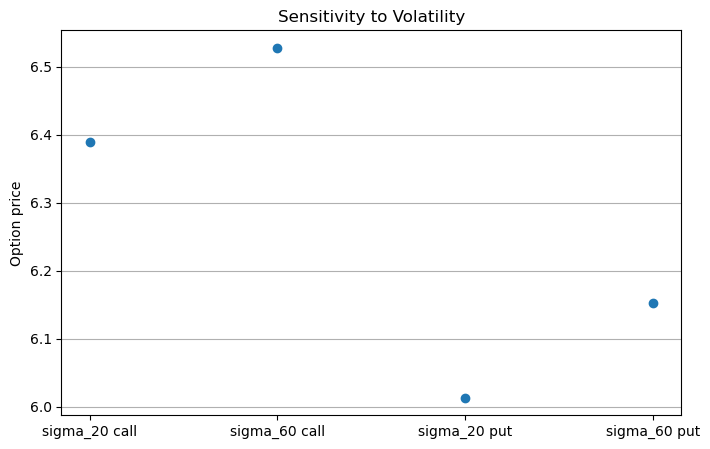

,Parameter,Call price,Put price
0,r = 0%,6.2067,6.2067
1,r = 2%,6.3889,6.0133
2,r = 4%,6.5744,5.8240
3,sigma_20,6.3889,6.0133
4,sigma_60,6.5279,6.1522
5,T = 30d,6.3889,6.0133
6,T = 90d,11.2749,10.1506


In [9]:
r_table = pd.DataFrame([{"Parameter": "r = 0%", "Call price": bs_call(S0, K_atm, T_30, 0.00, sigma_20), "Put price": bs_put(S0, K_atm, T_30, 0.00, sigma_20)},
    {"Parameter": "r = 2%", "Call price": bs_call(S0, K_atm, T_30, 0.02, sigma_20), "Put price": bs_put(S0, K_atm, T_30, 0.02, sigma_20)},
    {"Parameter": "r = 4%", "Call price": bs_call(S0, K_atm, T_30, 0.04, sigma_20), "Put price": bs_put(S0, K_atm, T_30, 0.04, sigma_20)},]).round(4)

sigma_table = pd.DataFrame([{"Parameter": "sigma_20", "Call price": bs_call(S0, K_atm, T_30, r, sigma_20), "Put price": bs_put(S0, K_atm, T_30, r, sigma_20)},
    {"Parameter": "sigma_60", "Call price": bs_call(S0, K_atm, T_30, r, sigma_60), "Put price": bs_put(S0, K_atm, T_30, r, sigma_60)},]).round(4)

T_table = pd.DataFrame([{"Parameter": "T = 30d", "Call price": bs_call(S0, K_atm, T_30, r, sigma_20), "Put price": bs_put(S0, K_atm, T_30, r, sigma_20)},
    {"Parameter": "T = 90d", "Call price": bs_call(S0, K_atm, T_90, r, sigma_20), "Put price": bs_put(S0, K_atm, T_90, r, sigma_20)},]).round(4)

r_table, sigma_table, T_table


plt.figure(figsize=(8,5))
plt.scatter(["sigma_20 call", "sigma_60 call", "sigma_20 put", "sigma_60 put"],
    [sigma_table["Call price"].iloc[0],
        sigma_table["Call price"].iloc[1],
        sigma_table["Put price"].iloc[0],
        sigma_table["Put price"].iloc[1],])
plt.title("Sensitivity to Volatility")
plt.ylabel("Option price")
plt.grid(True, axis="y")
plt.show()


summary_sensitivity = pd.DataFrame({"Parameter": ["r = 0%", "r = 2%", "r = 4%", "sigma_20", "sigma_60", "T = 30d", "T = 90d"],
    "Call price": [
        r_table["Call price"].iloc[0],
        r_table["Call price"].iloc[1],
        r_table["Call price"].iloc[2],
        sigma_table["Call price"].iloc[0],
        sigma_table["Call price"].iloc[1],
        T_table["Call price"].iloc[0],
        T_table["Call price"].iloc[1],],
    "Put price": [r_table["Put price"].iloc[0],
        r_table["Put price"].iloc[1],
        r_table["Put price"].iloc[2],
        sigma_table["Put price"].iloc[0],
        sigma_table["Put price"].iloc[1],
        T_table["Put price"].iloc[0],
        T_table["Put price"].iloc[1],]}).round(4)

summary_sensitivity

Main observations:
- Higher rates increase call prices and decrease put prices.
- Higher volatility increases both call and put prices.
- Longer maturities increase option values.

## Conclusion

This summary notebook shows that:
- Black-Scholes provides a fast analytical benchmark
- Greeks help interpret price sensitivities
- Monte Carlo converges towards the Black-Scholes result
- sensitivity analysis highlights the role of key pricing inputs